In [ ]:
import random
import math
from collections import defaultdict
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt


class BlackJack:
    deck_template = {
        11: 4,
        10: 16,
        9: 4,
        8: 4,
        7: 4,
        6: 4,
        5: 4,
        4: 4,
        3: 4,
        2: 4
    }

    def __init__(self):
        self.deck = BlackJack.deck_template.copy()
        self.player_hand = []
        self.dealer_hand = []
        self.deal()

    def draw(self):
        """Draw a card from the deck."""
        cards, weights = list(self.deck.keys()), list(self.deck.values())
        card = random.choices(cards, weights=weights)[0]
        self.deck[card] -= 1
        if self.deck[card] == 0:
            del self.deck[card]
        return card

    def hand_value(self, hand):
        """Return (hard_sum, soft_sum) for a hand."""
        hard = sum(1 if c == 11 else c for c in hand)
        soft = hard
        aces = hand.count(11)
        while aces > 0 and soft + 10 <= 21:
            soft += 10
            aces -= 1
        return hard, soft

    def deal(self):
        """Initial deal for player and dealer."""
        self.player_hand = [self.draw()]
        self.dealer_hand = [self.draw()]
        self.player_hand.append(self.draw())
        self.dealer_hand.append(self.draw())

    def player_values(self):
        return self.hand_value(self.player_hand)

    def dealer_values(self):
        return self.hand_value(self.dealer_hand)

    @property
    def dealer_shown(self):
        return self.dealer_hand[1]

    def dealer_play(self):
        """Dealer hits until reaching hard/soft ≥ 17."""
        while True:
            hard, soft = self.dealer_values()
            best = soft if soft <= 21 else hard
            if best >= 17:
                return best
            self.dealer_hand.append(self.draw())

    def result(self):
        """Compute reward for player."""
        player_hard, player_soft = self.player_values()
        player_best = player_soft if player_soft <= 21 else player_hard
        if player_best > 21:
            return -1  # player busts

        dealer_best = self.dealer_play()
        if dealer_best > 21:
            return 1
        if player_best > dealer_best:
            return 1
        elif player_best == dealer_best:
            return 0
        else:
            return -1


Win rate: 40.92% after 1000000 rounds


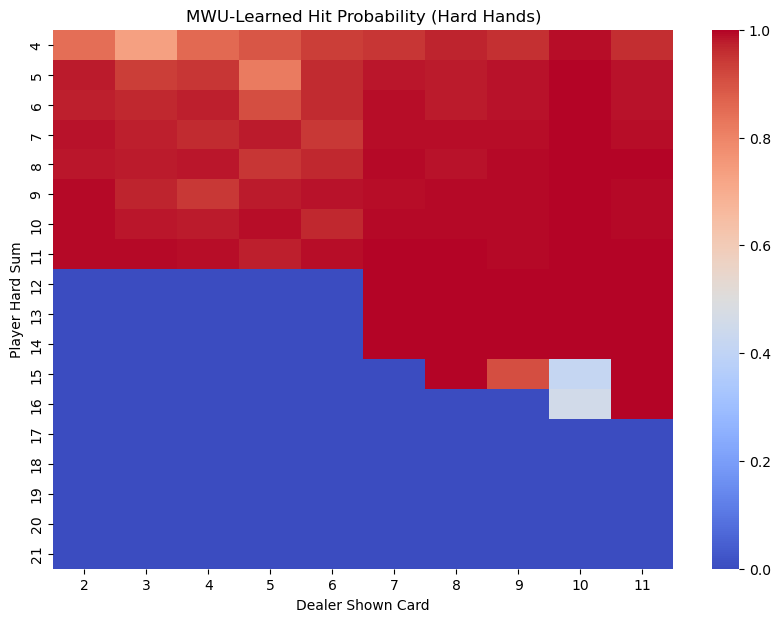

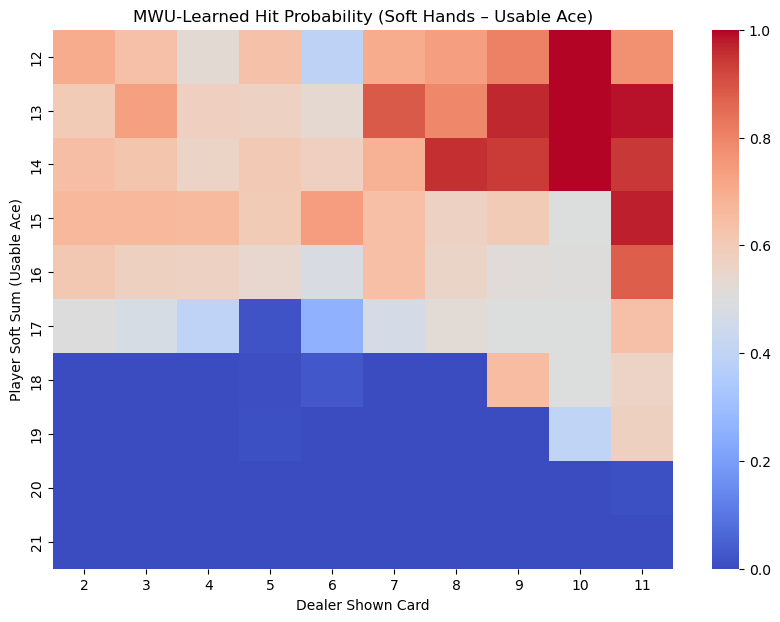

In [73]:

class MWUAgent:
    def __init__(self, eta=0.05):
        self.eta = eta
        self.weights = defaultdict(lambda: [1.0, 1.0])  # [hit, stand]

    def policy(self, state):
        w_hit, w_stand = self.weights[state]
        if not math.isfinite(w_hit) or not math.isfinite(w_stand):
            if math.isinf(w_hit) and not math.isinf(w_stand):
                self.weights[state] = [1.0, 0.0]
                return [1.0, 0.0]
            elif math.isinf(w_stand) and not math.isinf(w_hit):
                self.weights[state] = [0.0, 1.0]
                return [0.0, 1.0]
            self.weights[state] = [1.0, 1.0]
            return [0.5, 0.5]

        w_hit = min(max(w_hit, 1e-9), 1e9)
        w_stand = min(max(w_stand, 1e-9), 1e9)
        total = w_hit + w_stand
        return [w_hit / total, w_stand / total]

    def act(self, state):
        probs = self.policy(state)
        return random.choices(["hit", "stand"], weights=probs)[0]

    def update(self, state, action, reward):
        idx = 0 if action == "hit" else 1
        w = self.weights[state]
        w[idx] *= math.exp(self.eta * reward)
        self.weights[state] = w


def simulate(episodes=100000):
    agent = MWUAgent(eta=0.1)
    results = []

    for _ in range(episodes):
        env = BlackJack()
        hard, soft = env.player_values()
        dealer_card = env.dealer_shown
        has_ace = 11 in env.player_hand
        state = (dealer_card, hard, soft) if has_ace else (dealer_card, soft)
        done = False

        while not done:
            action = agent.act(state)

            if action == "hit":
                env.player_hand.append(env.draw())
                hard, soft = env.player_values()
                has_ace = 11 in env.player_hand
                if min(hard, soft) > 21:
                    reward = -1
                    done = True
                else:
                    state = (dealer_card, hard, soft) if has_ace else (dealer_card, soft)
                    continue
            else:
                reward = env.result()
                done = True

            agent.update(state, action, reward)
            results.append(reward)

    win_rate = (sum(1 for r in results if r == 1) / len(results)) * 100
    print(f"Win rate: {win_rate:.2f}% after {episodes} rounds")

    # === Visualization ===
    # Separate hard and soft state maps
    data_hard, data_soft = [], []

    for state, (w_hit, w_stand) in agent.weights.items():
        hit_prob = w_hit / (w_hit + w_stand)

        if len(state) == 2:
            dealer, total = state
            data_hard.append({
                "Dealer": dealer,
                "PlayerSum": total,
                "HitProb": hit_prob
            })
        elif len(state) == 3:
            dealer, hard, soft = state
            data_soft.append({
                "Dealer": dealer,
                "PlayerSum": soft,
                "HitProb": hit_prob
            })

    # Helper to plot a dataframe if nonempty
    def plot_state_heatmap(df, title, ylabel):
        if not df:
            return
        df = pd.DataFrame(df)
        df_mean = df.groupby(["PlayerSum", "Dealer"], as_index=False)["HitProb"].mean()
        pivot = df_mean.pivot(index="PlayerSum", columns="Dealer", values="HitProb")

        plt.figure(figsize=(10, 7))
        sns.heatmap(pivot, cmap="coolwarm", vmin=0, vmax=1)
        plt.title(title)
        plt.xlabel("Dealer Shown Card")
        plt.ylabel(ylabel)
        plt.show()

    # --- Three plots ---
    plot_state_heatmap(data_hard,
                    "MWU-Learned Hit Probability (Hard Hands)",
                    "Player Hard Sum")
    plot_state_heatmap(data_soft,
                    "MWU-Learned Hit Probability (Soft Hands – Usable Ace)",
                    "Player Soft Sum (Usable Ace)")


    return agent



trained_agent = simulate(1000000)


We can see that under MWU our agent notices the dealer's threshold to hit and adjusts weights to allow the dealer to bust. Where human players would likely hit on 12 and dealer showing 6 to beat a possible hidden 16 or 17, our MWU agent finds more success standing on 12 and letting the dealer possibly bust when it's known they will hit until 17.\
When our agent has an ace in-hand, it tends to hit up to 17 with safety of falling back on the hard sum (treating the ace as 1). We see that the agent gets biased to hit on higher hands the higher the dealer's shown card is.

Win rate: 40.51% after 10000000 rounds


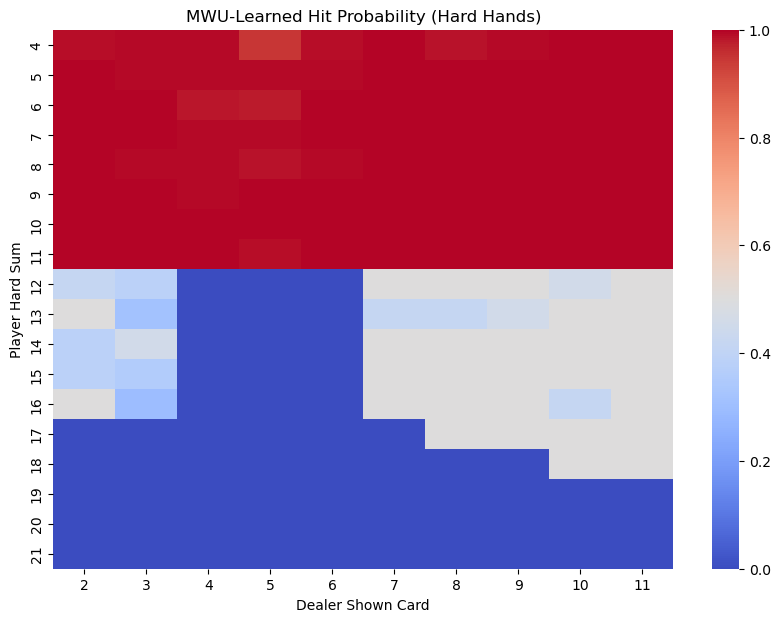

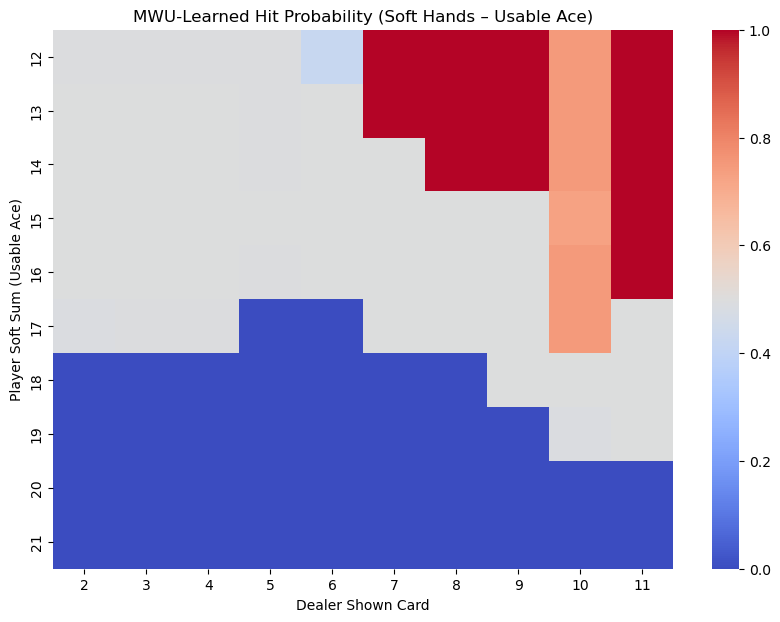

In [74]:
long_time_player = simulate(10000000)

After many more iterations we see a SLIGHTY lower win rate. I believe 42% is as high as it got while messing around with design+hyperparams\
Instead, our weights are much more certain about what action to take. We find "certain uncertainty" when holding 12-16 and dealer isnt showing 14-16, meaning our agent's action doesn't mean as much to the outcome of the hand, and chooses random actions rather than selecting hit or stand. The agent always hits below 12 since there is never a risk to bust and acts based on the dealer when holding an ace.\
We see less certainty when the dealer shows a 10, we expect this state to occur more than the others since there are more 10s in the deck than other values, we also see that the agent is willing to bet on higher values, really using its safety on soft sum to try and beat the dealer in case they have a strong hidden card.